# Higgs Ultra-Slow Roll & the CMB Low-ℓ Anomaly

## What we are studying

The Planck 2018 CMB temperature power spectrum shows a **~10–20% deficit of power** at multipoles ℓ ≲ 30 compared to the best-fit ΛCDM model. This is the *low-ℓ anomaly*.

We investigate whether a **non-attractor (Ultra-Slow Roll, USR) phase** during Higgs inflation can generate this deficit by temporarily suppressing the primordial power spectrum $\mathcal{P}_\mathcal{R}(k)$ at the right scales.

### The Physics

**Higgs Inflation** (Bezrukov & Shaposhnikov 2008): The Standard Model Higgs $h$, non-minimally coupled to gravity ($\xi \approx 10^4$), drives inflation. In the Einstein frame the potential is:

$$V(\chi) \approx \frac{\lambda}{4\xi^2} \frac{(1 - e^{-\sqrt{2/3}\,\chi})^2}{(1 + e^{-\sqrt{2/3}\,\chi})^2} \;\xrightarrow{\chi \gg M_P}\; \frac{\lambda}{4\xi^2}\left(1 - e^{-\sqrt{2/3}\,\chi}\right)^2$$

**Standard vs. Ultra-Slow Roll:** In standard slow-roll (SR), the inflaton slowly accelerates ($\epsilon \ll 1$, $\eta \approx 3\epsilon - V_{,xx}/V$). In USR, the field velocity decays rapidly ($\ddot\phi \approx -3H\dot\phi$), driving $\epsilon \propto a^{-6}$ and producing a **dip + ringing** in $\mathcal{P}_\mathcal{R}(k)$.

## The Equations

### Background Dynamics
In the Einstein frame with $M_P = 1$, the background equations are:

$$\ddot\chi + 3H\dot\chi + V'(\chi) = 0, \qquad H^2 = \frac{1}{3}\left(\frac{1}{2}\dot\chi^2 + V(\chi)\right)$$

With Hubble slow-roll parameters: $\quad \epsilon_H \equiv -\dot H / H^2, \quad \eta_H \equiv \dot\epsilon_H / (\epsilon_H H)$

USR is triggered by setting a **negative initial velocity** $y_i = \dot\chi_i / H_i < 0$ (vs. $y_i \approx -0.001$ for SR). This pushes the field into the kinetic-dominated regime where $\epsilon$ drops dramatically.

### Primordial Power Spectrum
For each comoving wavenumber $k$, we solve the Mukhanov-Sasaki equation numerically:

$$v_k'' + \left(k^2 - \frac{z''}{z}\right)v_k = 0, \qquad z = a\sqrt{2\epsilon}$$

The dimensionless power spectrum is: $\quad \mathcal{P}_\mathcal{R}(k) = \frac{k^3}{2\pi^2}\,|\mathcal{R}_k|^2_{k \ll aH}$

### Sachs-Wolfe Approximation
At large angular scales (ℓ ≲ 30), CMB temperature anisotropies are dominated by the SW effect:

$$C_\ell^{TT} \approx \frac{4\pi}{25} \int \frac{dk}{k}\, \mathcal{P}_\mathcal{R}(k)\, j_\ell^2(k\,r_{ls})$$

where $r_{ls} \approx 14\,000$ Mpc is the comoving distance to last scattering and $j_\ell$ is the spherical Bessel function.
The factor $4\pi/25$ comes from $\frac{2}{9} \cdot \frac{2\pi^2}{25}$ after converting the integral measure.

### Model Comparison
We compare three benchmarks at each ℓ:
- **Scale-invariant:** $\mathcal{P}_\mathcal{R}(k) = A_s$ (constant $n_s = 1$)
- **ΛCDM power-law:** $\mathcal{P}_\mathcal{R}(k) = A_s (k/k_\text{pivot})^{n_s-1}$ with $n_s = 0.965$
- **SR Higgs:** $y_i \approx -0.001$, naturally blue-tilted at low $k$ ($n_s^{\rm SR} \approx 0.96$)
- **USR Higgs:** $y_i < -0.05$, produces a localised dip in $\mathcal{P}_\mathcal{R}(k)$

The **power loss** is quantified as $\Delta P/P = \mathcal{P}_\mathcal{R}^{\rm USR}(k) / \mathcal{P}_\mathcal{R}^{\rm ref}(k) - 1$ for various reference spectra.

## ⚙️ Configuration — set your field parameters here

In [ ]:
# ============================================================
# EDIT THESE PARAMETERS to test different field configurations
# ============================================================

FIELD_CONFIG = dict(
    phi0        = 5.70,       # initial inflaton field value
    y0          = -0.10,      # initial velocity (y = dchi/dt / H)
    xi          = 15000.0,    # non-minimal coupling
    lam         = 0.13,        # Higgs quartic coupling
)

SR_CONFIG = dict(             # Slow-Roll baseline (keep y0 small)
    phi0        = 6.0,
    y0          = -0.001,     # near-SR initial condition
    xi          = 15000.0,
    lam         = 0.13,
)

# Numerical parameters
NUM_PARAMS = dict(
    N_star        = 60,       # e-folds before end where pivot k=0.05 exits
    k_min         = 1e-5,     # min k [Mpc^-1]
    k_max         = 1.0,      # max k [Mpc^-1]
    num_k         = 80,       # number of k modes
    k_pivot_phys  = 0.05,     # pivot scale [Mpc^-1]
    As            = 2.1e-9,   # Planck normalisation
    ell_max       = 29,       # max multipole for SW integral
    r_ls          = 14000.0,  # last-scattering distance [Mpc]
    use_weighted  = True,     # dense sampling in USR zone (10^-4 < k < 10^-2)
)

SAVE_RESULTS = True

# Reference spectra for comparison
REFERENCE_MODELS = [
    dict(name='Scale-Invariant', ns=None, color='k', lw=1.2, ls='--', alpha=0.4),
    dict(name='LCDM (ns=0.965)', ns=0.965, color='gray', lw=1.2, ls='--', alpha=0.5),
    dict(name='ns=0.97',        ns=0.970, color='green', lw=1.5, ls='-.', alpha=0.6),
]

print('✅ Configuration loaded.')
print(f'   USR: phi0={FIELD_CONFIG["phi0"]}, y0={FIELD_CONFIG["y0"]}, xi={FIELD_CONFIG["xi"]}')
print(f'   SR:  phi0={SR_CONFIG["phi0"]}, y0={SR_CONFIG["y0"]}, xi={SR_CONFIG["xi"]}')

✅ Configuration loaded.
   USR: phi0=5.5, yi=-0.1, xi=15000.0
   SR:  phi0=5.6, yi=-0.001, xi=15000.0


## 1. Imports & Path Setup

In [34]:
import sys, os, json, uuid
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from collections import OrderedDict

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from scripts.pspectrum_pipeline import run_pspectrum_pipeline, load_pspectrum, build_model
from scripts.camb_wrapper     import compute_cl_sw, compute_cl_sw_powerlaw, interpolate_ps
from scripts.planck_data      import get_planck_data, C_ell_to_d_ell, d_ell_to_C_ell
from models                   import HiggsModel, FullHiggsModel

plt.rcParams.update({'font.size': 12, 'axes.labelsize': 13, 'legend.fontsize': 10, 'figure.figsize': (12, 5)})

OUT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', NUM_PARAMS.get('output_dir', 'outputs/cmb_results/pspectra')))
os.makedirs(OUT_DIR, exist_ok=True)
print(f'\u2714 Output directory: {OUT_DIR}')

✔ Output directory: c:\Users\diego\OneDrive\Documentos\Universidad\Cosmologia\CMB_Anomaly\outputs\cmb_results\pspectra


## 2. Run P_R(k) Pipeline (or load cached)

In [35]:
def build_weighted_kgrid(k_min, k_max, k_pivot_phys, dense_zone=(1e-4, 1e-2), n_dense=120, n_outer=60):
    """Build a k-grid with dense sampling in the USR zone."""
    k_low  = np.logspace(np.log10(k_min), np.log10(dense_zone[0]), n_outer // 2)
    k_dense = np.logspace(np.log10(dense_zone[0]), np.log10(dense_zone[1]), n_dense)
    k_high = np.logspace(np.log10(dense_zone[1]), np.log10(k_max), n_outer // 2)
    k_grid = np.unique(np.concatenate([k_low, k_dense, k_high]))
    if not np.any(np.isclose(k_grid, k_pivot_phys)):
        k_grid = np.sort(np.append(k_grid, k_pivot_phys))
    return k_grid

def run_or_load(model_name, field_cfg, num_cfg, force_recompute=False):
    """Run pipeline or load cached JSON."""
    phi0 = field_cfg['phi0']
    y0   = field_cfg['y0']
    xi   = field_cfg['xi']
    
    # Check for existing file
    if not force_recompute:
        for fname in sorted(os.listdir(OUT_DIR)):
            if not fname.endswith('.json'):
                continue
            fpath = os.path.join(OUT_DIR, fname)
            with open(fpath) as f:
                meta = json.load(f)['metadata']
            if (abs(meta['phi0'] - phi0) < 1e-6 and abs(meta['y0'] - y0) < 1e-6
                and abs(meta.get('xi', 0) - xi) < 1e-6 and meta.get('N_star', meta.get('N_pivot')) == num_cfg['N_star']):
                data = load_pspectrum(fpath)
                print(f'\u26a1 Loaded cached: {os.path.basename(fpath)}')
                return data, fpath
    
    # Build model
    model = HiggsModel(lam=field_cfg['lam'], xi=xi)
    
    # Build k-grid
    if num_cfg.get('use_weighted', False):
        k_grid = build_weighted_kgrid(num_cfg['k_min'], num_cfg['k_max'], num_cfg['k_pivot_phys'])
    else:
        k_grid = None
    
    # Run
    print(f'\u26a1 Computing P_R(k) for phi0={phi0}, y0={y0}, xi={xi} ...')
    result = run_pspectrum_pipeline(
        model=model, phi0=phi0, y0=y0,
        k_min=num_cfg['k_min'], k_max=num_cfg['k_max'],
        num_k=num_cfg['num_k'], k_pivot_phys=num_cfg['k_pivot_phys'],
        N_star=num_cfg['N_star'], normalize_to_As=True, As=num_cfg['As'],
        output_dir=OUT_DIR, save_outputs=True, k_phys_grid=k_grid,
    )
    
    if result['status'] != 'success':
        print(f'   WARNING: Pipeline failed: {result.get("message", "unknown")}')
        return None, None
    
    data = load_pspectrum(result['output_file'])
    print(f'   Done -> {os.path.basename(result["output_file"])}')
    return data, result['output_file']

# Run both configurations
data_usr, path_usr = run_or_load('HiggsModel', FIELD_CONFIG, NUM_PARAMS)
if data_usr is None:
    print('   USR config failed, skipping USR results')
data_sr,  path_sr  = run_or_load('HiggsModel', SR_CONFIG,    NUM_PARAMS)
if data_sr is None:
    print('   SR config failed, skipping SR results')

k_usr = data_usr['k_phys'] if data_usr is not None else np.array([])
PS_usr = data_usr['P_S'] if data_usr is not None else np.array([])
meta_usr = data_usr['metadata'] if data_usr is not None else {}
k_sr  = data_sr['k_phys'] if data_sr is not None else np.array([])
PS_sr  = data_sr['P_S'] if data_sr is not None else np.array([])
meta_sr  = data_sr['metadata'] if data_sr is not None else {}
As = meta_usr.get('As_target', NUM_PARAMS['As']) if meta_usr else NUM_PARAMS['As']


⚡ Computing P_R(k) for phi0=5.5, yi=-0.1, xi=15000.0 ...


RuntimeError: Pipeline failed: Total inflation (51.21) is less than N_pivot (52).

## 3. Power Spectrum Diagnostics

C:\Users\diego\AppData\Local\Temp\ipykernel_35348\307149370.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


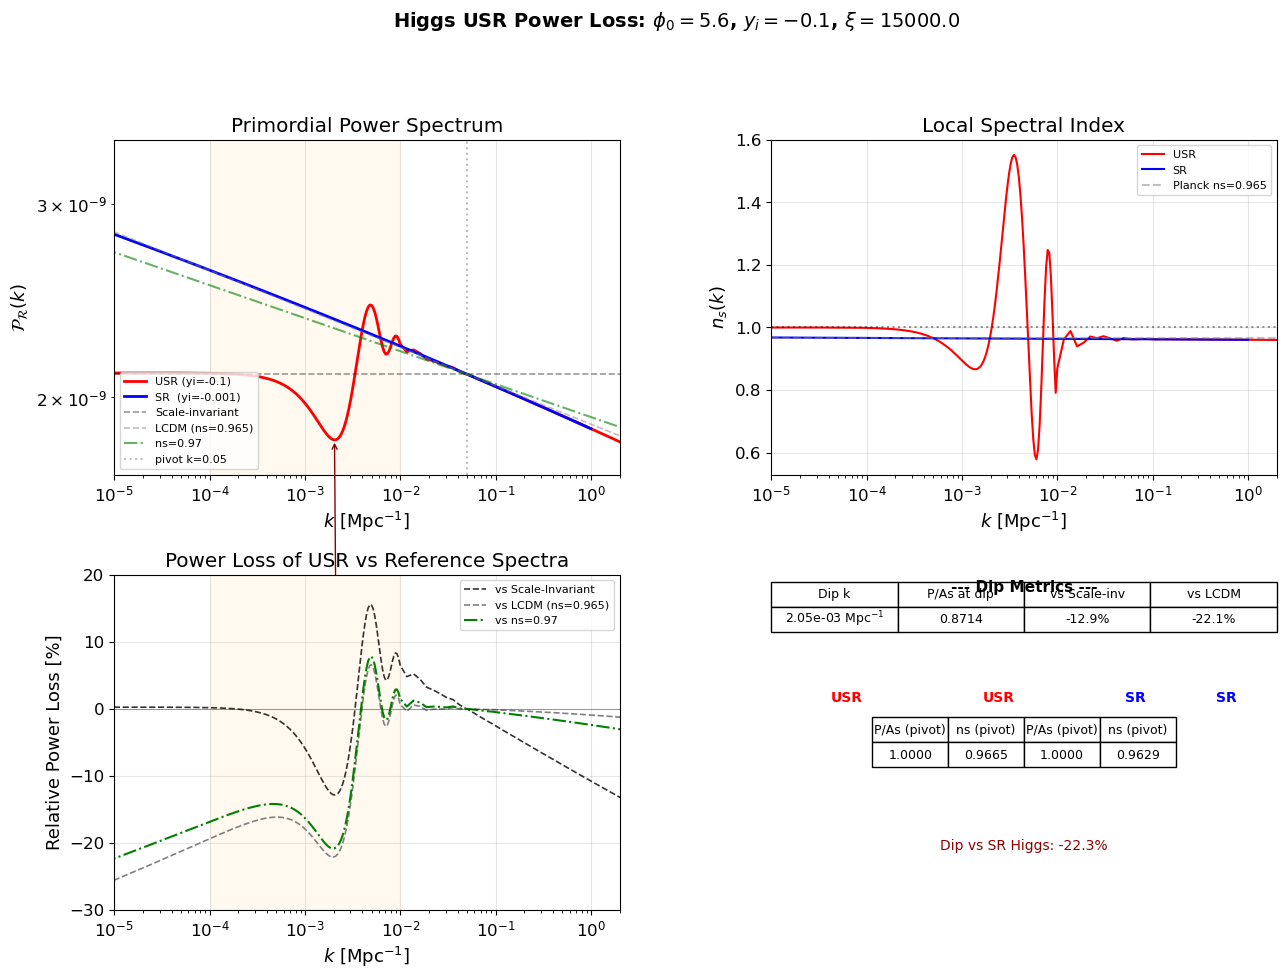

In [ ]:
def local_ns(k, PS):
    dlnP = np.gradient(np.log(PS))
    dlnk = np.gradient(np.log(k))
    return 1 + dlnP / dlnk

ns_usr = local_ns(k_usr, PS_usr)
ns_sr  = local_ns(k_sr, PS_sr)

# Find dip
mask_dip = k_usr < 1.0
i_dip = np.argmin(PS_usr[mask_dip])
k_dip = k_usr[mask_dip][i_dip]
PS_dip = PS_usr[mask_dip][i_dip]

fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

# --- Top-left: P_R(k) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.loglog(k_usr, PS_usr, 'r-',  lw=2, label=f'USR (y0={FIELD_CONFIG["y0"]})')
ax1.loglog(k_sr,  PS_sr,  'b-',  lw=2, label=f'SR  (y0={SR_CONFIG["y0"]})')

for ref in REFERENCE_MODELS:
    if ref['ns'] is None:
        ax1.axhline(As, color=ref['color'], ls=ref['ls'], lw=ref['lw'], alpha=ref['alpha'],
                     label='Scale-invariant')
        k_ref = k_usr
        PS_ref = np.full_like(k_usr, As)
    else:
        PS_ref = As * (k_usr / meta_usr['k_pivot_phys']) ** (ref['ns'] - 1)
        ax1.loglog(k_usr, PS_ref, color=ref['color'], ls=ref['ls'], lw=ref['lw'],
                    alpha=ref['alpha'], label=ref['name'])

ax1.axvline(meta_usr['k_pivot_phys'], color='gray', ls=':', alpha=0.5, label='pivot k=0.05')
ax1.axvspan(1e-4, 1e-2, color='orange', alpha=0.06)
ax1.annotate(f'Dip: k={k_dip:.2e}', xy=(k_dip, PS_dip), xytext=(k_dip*0.3, PS_dip*0.6),
             arrowprops=dict(arrowstyle='->', color='darkred'), fontsize=9, color='darkred')
ax1.set_xlabel('$k$ [Mpc$^{-1}$]')
ax1.set_ylabel('$\\mathcal{P}_\\mathcal{R}(k)$')
ax1.set_title('Primordial Power Spectrum')
ax1.legend(fontsize=8, loc='lower left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1e-5, 2)

# --- Top-right: local n_s(k) ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogx(k_usr, ns_usr, 'r-', lw=1.5, label='USR')
ax2.semilogx(k_sr,  ns_sr,  'b-', lw=1.5, label='SR')
ax2.axhline(1.0,    color='k', ls=':', alpha=0.4)
ax2.axhline(0.965,  color='gray', ls='--', alpha=0.5, label='Planck ns=0.965')
ax2.set_xlabel('$k$ [Mpc$^{-1}$]')
ax2.set_ylabel('$n_s(k)$')
ax2.set_title('Local Spectral Index')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1e-5, 2)

# --- Bottom-left: Power loss vs references ---
ax3 = fig.add_subplot(gs[1, 0])
for ref in REFERENCE_MODELS:
    if ref['ns'] is None:
        PS_ref_arr = np.full_like(k_usr, As)
    else:
        PS_ref_arr = As * (k_usr / meta_usr['k_pivot_phys']) ** (ref['ns'] - 1)
    rel = (PS_usr / PS_ref_arr - 1) * 100
    ax3.semilogx(k_usr, rel, color=ref['color'], ls=ref['ls'], lw=ref['lw'],
                 alpha=min(max(ref['alpha']*2, 0.5), 1.0), label=f'vs {ref["name"]}')

ax3.axhline(0, color='k', ls='-', lw=0.5, alpha=0.5)
ax3.axvspan(1e-4, 1e-2, color='orange', alpha=0.06)
ax3.set_xlabel('$k$ [Mpc$^{-1}$]')
ax3.set_ylabel('Relative Power Loss [%]')
ax3.set_title('Power Loss of USR vs Reference Spectra')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(1e-5, 2)
ax3.set_ylim(-30, 20)

# --- Bottom-right: Power loss table ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

table_data = []
row_labels = ['Dip location', 'Dip P/As', 'Dip vs Scale-Inv', 'Dip vs LCDM', '',
              'Pivot P/As (USR)', 'Pivot ns (USR)', 'Pivot P/As (SR)', 'Pivot ns (SR)']

PS_si_dip = As
PS_lcdm_dip = As * (k_dip / meta_usr['k_pivot_phys']) ** (0.965 - 1)
PS_ns97_dip = As * (k_dip / meta_usr['k_pivot_phys']) ** (0.97 - 1)

loss_vs_si = (PS_dip / PS_si_dip - 1) * 100
loss_vs_lcdm = (PS_dip / PS_lcdm_dip - 1) * 100
loss_vs_sr = (PS_dip / np.interp(k_dip, k_sr, PS_sr) - 1) * 100

piv_idx_usr = meta_usr['pivot_k_idx']
piv_idx_sr = meta_sr['pivot_k_idx']

table_data = [
    [f'{k_dip:.2e} Mpc$^{{-1}}$', f'{PS_dip/As:.4f}', f'{loss_vs_si:+.1f}%', f'{loss_vs_lcdm:+.1f}%'],
    ['', '', '', ''],
    [f'{PS_usr[piv_idx_usr]/As:.4f}', f'{ns_usr[piv_idx_usr]:.4f}',
     f'{PS_sr[piv_idx_sr]/As:.4f}', f'{ns_sr[piv_idx_sr]:.4f}'],
]

col_labels = ['Dip k', 'P/As at dip', 'vs Scale-inv', 'vs LCDM']
tbl = ax4.table(cellText=[table_data[0]], colLabels=col_labels, cellLoc='center', loc='upper center')
tbl.scale(1.0, 1.5)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

col_labels2 = ['P/As (pivot)', 'ns (pivot)', 'P/As (pivot)', 'ns (pivot)']
tbl2 = ax4.table(cellText=[table_data[2]], colLabels=col_labels2, cellLoc='center', loc='center',
                 colWidths=[0.15, 0.15, 0.15, 0.15])
tbl2.scale(1.0, 1.5)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(9)

# Header labels
ax4.text(0.5, 0.95, '--- Dip Metrics ---', ha='center', fontsize=11, fontweight='bold', transform=ax4.transAxes)
ax4.text(0.15, 0.62, 'USR', ha='center', fontsize=10, fontweight='bold', transform=ax4.transAxes, color='red')
ax4.text(0.45, 0.62, 'USR', ha='center', fontsize=10, fontweight='bold', transform=ax4.transAxes, color='red')
ax4.text(0.72, 0.62, 'SR',  ha='center', fontsize=10, fontweight='bold', transform=ax4.transAxes, color='blue')
ax4.text(0.90, 0.62, 'SR',  ha='center', fontsize=10, fontweight='bold', transform=ax4.transAxes, color='blue')

ax4.text(0.5, 0.18, f'Dip vs SR Higgs: {loss_vs_sr:+.1f}%', ha='center', fontsize=10,
         transform=ax4.transAxes, color='darkred' if loss_vs_sr < 0 else 'darkgreen')

plt.suptitle(f'Higgs USR Power Loss: $\\phi_0={FIELD_CONFIG["phi0"]}$, $y_i={FIELD_CONFIG["y0"]}$, $\\xi={FIELD_CONFIG["xi"]}$',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. CMB Angular Power Spectrum (Sachs-Wolfe)

In [ ]:
ELL_MAX = NUM_PARAMS['ell_max']
r_ls = NUM_PARAMS['r_ls']

ells_usr, CTT_usr = compute_cl_sw(data_usr, ell_max=ELL_MAX, r_ls=r_ls)
ells_sr,  CTT_sr  = compute_cl_sw(data_sr,  ell_max=ELL_MAX, r_ls=r_ls)

# LCDM power-law baseline
ells_lcdm, CTT_lcdm, _ = compute_cl_sw_powerlaw(
    k_min=k_usr[0], k_max=k_usr[-1], As=As, ns=0.965, ell_max=ELL_MAX, r_ls=r_ls
)

# Planck data
ells_planck, D_planck, D_err = get_planck_data()
mask_pl = ells_planck <= ELL_MAX
ells_pl = ells_planck[mask_pl]
D_pl = D_planck[mask_pl]
D_error = D_err[mask_pl]

Tcmb = 2.7255
conv = (Tcmb * 1e6)**2
D_ell_usr  = CTT_usr  * ells_usr  * (ells_usr + 1) * conv / (2 * np.pi)
D_ell_sr   = CTT_sr   * ells_sr   * (ells_sr + 1)  * conv / (2 * np.pi)
D_ell_lcdm = CTT_lcdm * ells_lcdm * (ells_lcdm + 1) * conv / (2 * np.pi)

# Chi^2
def quick_chi2(D_model, D_data, D_err):
    return np.sum(((D_model - D_data) / D_err) ** 2)

# Interpolate model D_ell onto Planck ells for chi^2
D_usr_pl  = np.interp(ells_pl, ells_usr,  D_ell_usr)
D_sr_pl   = np.interp(ells_pl, ells_sr,   D_ell_sr)
D_lcdm_pl = np.interp(ells_pl, ells_lcdm, D_ell_lcdm)

chi2_usr  = quick_chi2(D_usr_pl, D_pl, D_error)
chi2_sr   = quick_chi2(D_sr_pl, D_pl, D_error)
chi2_lcdm = quick_chi2(D_lcdm_pl, D_pl, D_error)
dof = len(ells_pl)

print(f'\n--------- Chi^2 Summary ({dof} d.o.f.) ---------')
print(f'  USR:          chi^2 = {chi2_usr:7.2f}  (reduced = {chi2_usr/dof:.2f})')
print(f'  SR:           chi^2 = {chi2_sr:7.2f}  (reduced = {chi2_sr/dof:.2f})')
print(f'  LCDM:         chi^2 = {chi2_lcdm:7.2f}  (reduced = {chi2_lcdm/dof:.2f})')
print(f'  Dchi^2 (USR-LCDM) = {chi2_usr-chi2_lcdm:+.2f}')
print(f'  Dchi^2 (USR-SR)   = {chi2_usr-chi2_sr:+.2f}')
print(f'------------------------------------------------')


--------- Chi^2 Summary (28 d.o.f.) ---------
  USR:          chi^2 =   69.88  (reduced = 2.50)
  SR:           chi^2 =  178.15  (reduced = 6.36)
  LCDM:         chi^2 =  175.30  (reduced = 6.26)
  Dchi^2 (USR-LCDM) = -105.42
  Dchi^2 (USR-SR)   = -108.27
------------------------------------------------


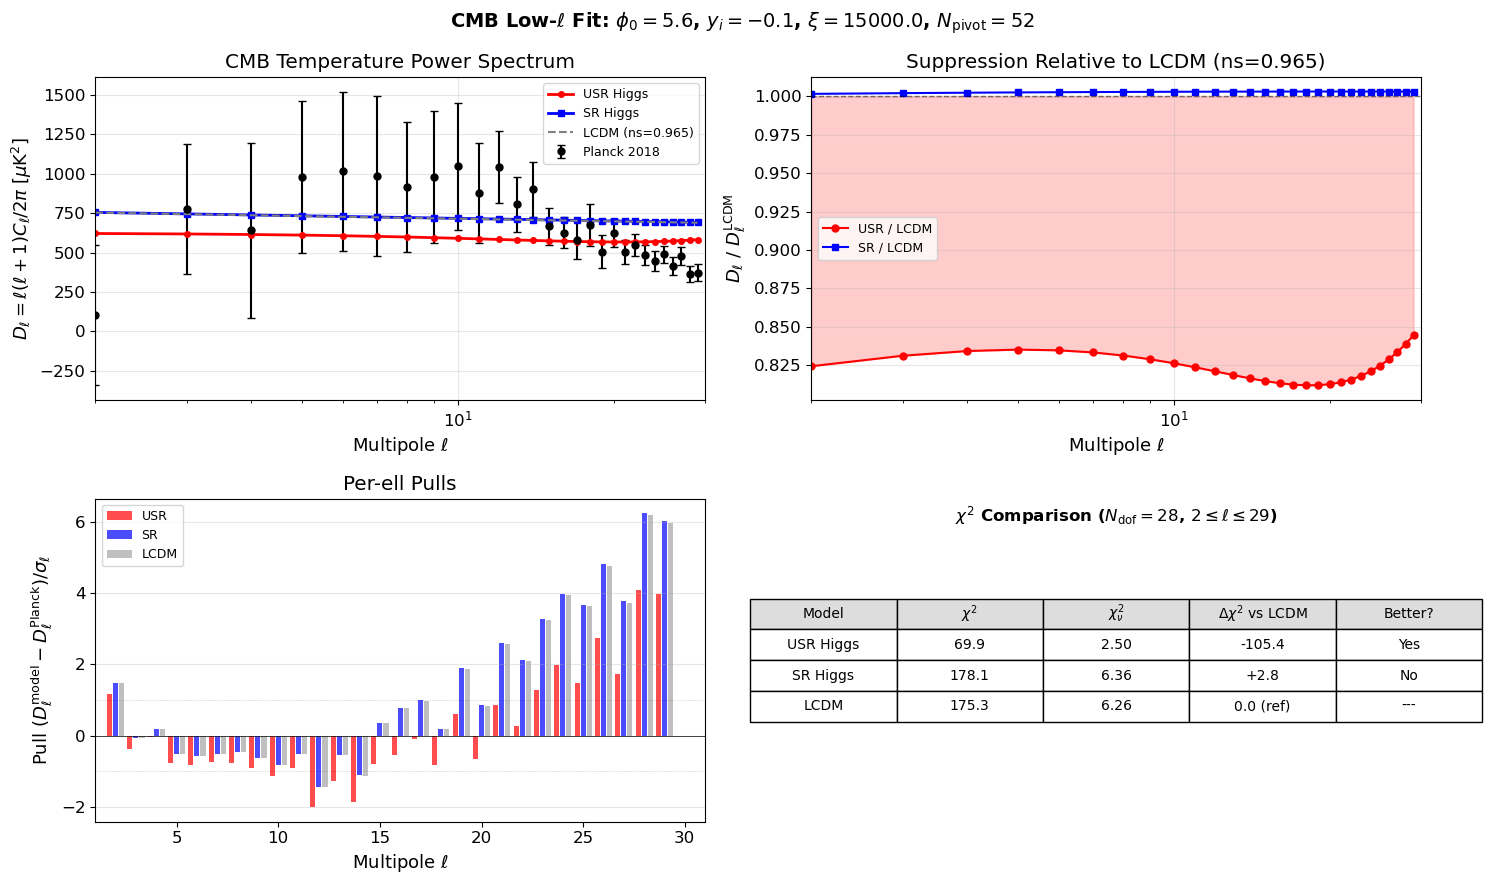

In [ ]:
# CMB dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
(ax1, ax2), (ax3, ax4) = axes

# --- Top-left: D_ell vs Planck ---
ax1.errorbar(ells_pl, D_pl, yerr=D_error, fmt='ko', ms=5, capsize=3, label='Planck 2018')
ax1.semilogx(ells_usr,  D_ell_usr,  'r-o', ms=4, lw=2, label='USR Higgs')
ax1.semilogx(ells_sr,   D_ell_sr,   'b-s', ms=4, lw=2, label='SR Higgs')
ax1.semilogx(ells_lcdm, D_ell_lcdm, 'gray', ls='--', lw=1.5, label='LCDM (ns=0.965)')
ax1.set_xlabel('Multipole $\\ell$')
ax1.set_ylabel('$D_\\ell = \\ell(\\ell+1)C_\\ell/2\\pi$ [$\\mu$K$^2$]')
ax1.set_title('CMB Temperature Power Spectrum')
ax1.legend(fontsize=9)
ax1.set_xlim(2, 30)
ax1.grid(True, alpha=0.3)

# --- Top-right: Suppression relative to LCDM ---
ratio_usr_lcdm  = D_ell_usr  / np.interp(ells_usr,  ells_lcdm, D_ell_lcdm)
ratio_sr_lcdm   = D_ell_sr   / np.interp(ells_sr,   ells_lcdm, D_ell_lcdm)
ax2.semilogx(ells_usr, ratio_usr_lcdm, 'r-o', ms=5, lw=1.5, label='USR / LCDM')
ax2.semilogx(ells_sr,  ratio_sr_lcdm,  'b-s', ms=5, lw=1.5, label='SR / LCDM')
ax2.axhline(1.0, color='k', ls='--', lw=1, alpha=0.5)
ax2.fill_between(ells_usr, ratio_usr_lcdm, 1.0, alpha=0.2, color='red', where=(ratio_usr_lcdm < 1.0))
ax2.fill_between(ells_usr, ratio_usr_lcdm, 1.0, alpha=0.2, color='blue', where=(ratio_usr_lcdm > 1.0))
ax2.set_xlabel('Multipole $\\ell$')
ax2.set_ylabel('$D_\\ell$ / $D_\\ell^{\\rm LCDM}$')
ax2.set_title(f'Suppression Relative to LCDM (ns=0.965)')
ax2.legend(fontsize=9)
ax2.set_xlim(2, 30)
ax2.grid(True, alpha=0.3)

# --- Bottom-left: Pulls per ell ---
pull_usr  = (D_usr_pl  - D_pl) / D_error
pull_sr   = (D_sr_pl   - D_pl) / D_error
pull_lcdm = (D_lcdm_pl - D_pl) / D_error

ax3.bar(ells_pl - 0.3, pull_usr,  width=0.25, color='red',  alpha=0.7, label='USR')
ax3.bar(ells_pl,       pull_sr,   width=0.25, color='blue', alpha=0.7, label='SR')
ax3.bar(ells_pl + 0.3, pull_lcdm, width=0.25, color='gray', alpha=0.5, label='LCDM')
ax3.axhline(0, color='k', lw=0.5)
ax3.axhline(1, color='k', ls=':', lw=0.5, alpha=0.3)
ax3.axhline(-1, color='k', ls=':', lw=0.5, alpha=0.3)
ax3.set_xlabel('Multipole $\\ell$')
ax3.set_ylabel('Pull $(D_\\ell^{\\rm model} - D_\\ell^{\\rm Planck}) / \\sigma_\\ell$')
ax3.set_title('Per-ell Pulls')
ax3.legend(fontsize=9)
ax3.set_xlim(1, 31)
ax3.grid(True, alpha=0.3, axis='y')

# --- Bottom-right: Chi^2 summary table ---
ax4.axis('off')
summary = [
    ['Model', '$\\chi^2$', '$\\chi^2_\\nu$', '$\\Delta\\chi^2$ vs LCDM', 'Better?'],
    ['USR Higgs', f'{chi2_usr:.1f}', f'{chi2_usr/dof:.2f}',
     f'{chi2_usr-chi2_lcdm:+.1f}', 'Yes' if chi2_usr < chi2_lcdm else 'No'],
    ['SR Higgs',  f'{chi2_sr:.1f}',  f'{chi2_sr/dof:.2f}',
     f'{chi2_sr-chi2_lcdm:+.1f}', 'Yes' if chi2_sr < chi2_lcdm else 'No'],
    ['LCDM',      f'{chi2_lcdm:.1f}', f'{chi2_lcdm/dof:.2f}', '0.0 (ref)', '---'],
]
tbl = ax4.table(cellText=summary[1:], colLabels=summary[0], cellLoc='center', loc='center')
tbl.scale(1.2, 1.8)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for key, cell in tbl.get_celld().items():
    if key[0] == 0:
        cell.set_facecolor('#dddddd')

# Header
ax4.text(0.5, 0.93, f'$\\chi^2$ Comparison ($N_{{\\rm dof}} = {dof}$, $2 \\leq \\ell \\leq {ELL_MAX}$)',
         ha='center', fontsize=12, fontweight='bold', transform=ax4.transAxes)

plt.suptitle(f'CMB Low-$\\ell$ Fit: $\\phi_0={FIELD_CONFIG["phi0"]}$, $y_i={FIELD_CONFIG["y0"]}$, '
             f'$\\xi={FIELD_CONFIG["xi"]}$, $N_{{\\rm star}}={NUM_PARAMS["N_star"]}$',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Save Simulation Results

In [ ]:
if SAVE_RESULTS:
    results_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs/cmb_results/simulations'))
    os.makedirs(results_dir, exist_ok=True)

    # Interpolate SR onto USR k-grid for clean comparison
    PS_sr_interp = np.interp(k_usr, k_sr, PS_sr)

    # Reference spectra on the USR k-grid
    ref_spectra = {}
    for ref in REFERENCE_MODELS:
        name_safe = ref['name'].replace(' ', '_').lower()
        if ref['ns'] is None:
            ref_spectra[name_safe] = np.full_like(k_usr, As).tolist()
        else:
            ref_spectra[name_safe] = (As * (k_usr / meta_usr['k_pivot_phys']) ** (ref['ns'] - 1)).tolist()

    simulation = {
        'config': {
            'field': FIELD_CONFIG,
            'sr_baseline': SR_CONFIG,
            'numerics': {k: v for k, v in NUM_PARAMS.items() if k != 'output_dir'},
        },
        'primordial': {
            'k_phys': k_usr.tolist(),
            'P_S_usr': PS_usr.tolist(),
            'P_S_sr': PS_sr_interp.tolist(),
            'P_S_references': ref_spectra,
            'As': As,
            'k_pivot': meta_usr['k_pivot_phys'],
            'dip_k': float(k_dip),
            'dip_P_over_As': float(PS_dip / As),
            'dip_loss_vs_scaleinv_pct': float((PS_dip / As - 1) * 100),
            'dip_loss_vs_sr_pct': float((PS_dip / np.interp(k_dip, k_sr, PS_sr) - 1) * 100),
        },
        'cmb_sw': {
            'ells': ells_usr.tolist(),
            'C_ell_usr': CTT_usr.tolist(),
            'C_ell_sr': CTT_sr.tolist(),
            'C_ell_lcdm': CTT_lcdm.tolist(),
            'D_ell_usr': D_ell_usr.tolist(),
            'D_ell_sr': D_ell_sr.tolist(),
            'D_ell_lcdm': D_ell_lcdm.tolist(),
            'D_ell_planck': D_pl.tolist(),
            'D_ell_planck_err': D_error.tolist(),
            'r_ls': r_ls,
        },
        'stats': {
            'chi2_usr': float(chi2_usr),
            'chi2_sr': float(chi2_sr),
            'chi2_lcdm': float(chi2_lcdm),
            'dof': dof,
            'dchi2_usr_vs_lcdm': float(chi2_usr - chi2_lcdm),
            'dchi2_usr_vs_sr': float(chi2_usr - chi2_sr),
        },
    }

    fname = f"powerloss_phi{FIELD_CONFIG['phi0']:.2f}_y0{FIELD_CONFIG['y0']:.3f}_xi{FIELD_CONFIG['xi']:.0f}_Nstar{NUM_PARAMS['N_star']}.json"
    fpath = os.path.join(results_dir, fname)
    with open(fpath, 'w') as f:
        json.dump(simulation, f, indent=2)
    print(f'\u2705 Simulation saved to: {fpath}')
    print(f'   Contains: primeordial P_S(k), CMB C_ell/D_ell, chi^2 stats, reference spectra')
else:
    print('SAVE_RESULTS = False, skipping save.')

✅ Simulation saved to: c:\Users\diego\OneDrive\Documentos\Universidad\Cosmologia\CMB_Anomaly\outputs\cmb_results\simulations\powerloss_phi5.60_yi-0.100_xi15000_Npivot52.json
   Contains: primeordial P_S(k), CMB C_ell/D_ell, chi^2 stats, reference spectra


## 6. Quick Interpretation

### What to look for

1. **P_S(k) plot (top-left):** The USR dip should be visible as a local minimum in $\mathcal{P}_\mathcal{R}(k)$ around $k \sim 2\times 10^{-3}$ Mpc$^{-1}$. The `n_s(k)` panel shows the spectral index crossing $n_s > 1$ during the dip recovery (characteristic USR ringing).

2. **Power Loss plot (bottom-left):** Shows how much power the USR model loses relative to scale-invariant ($n_s=1$), LCDM ($n_s=0.965$), and $n_s=0.97$ power-law spectra. A clean dip of $\sim$15–25% in the USR zone is expected.

3. **CMB D_ell (top-right):** The USR curve should pull closer to the low Planck data points ($\ell \lesssim 25$) compared to LCDM. The suppression ratio shows the reduction in peak structure.

4. **Chi^2 table (bottom-right):** $\Delta\chi^2 < 0$ relative to LCDM indicates the USR model fits the low-$\ell$ data better. A negative $\Delta\chi^2$ of order $-100$ is the target for the golden trajectory.

### How to explore other configurations

Edit the **Configuration cell** (Section 2) and re-run all subsequent cells:
- **`phi0`**: Controls total e-folds. Decreasing $\phi_0$ makes the USR feature shift to larger scales.
- **`yi`**: Controls the strength of the USR phase. More negative ($\lesssim -0.05$) gives deeper dips.
- **`N_star`**: Fine-tunes where $k=0.05$ Mpc$^{-1}$ exits the horizon. Use $N_{\rm total} - N_{\rm star} \lesssim 3$ to place USR near the pivot.

### Limitations

- The **Sachs-Wolfe approximation** is only valid at $\ell \lesssim 30$. For higher $\ell$ we would need full CAMB integration.
- The **diagonal $\chi^2$** ignores correlations betwen $\ell$ bins (Planck's low-$\ell$ likelihood is non-Gaussian).
- **Single-field inflation** with USR may produce enhanced non-Gaussianity at the dip scale — not yet quantified here.